In [1]:
import pandas as pd
import numpy as np


In [12]:
df=pd.read_excel(r"C:\Users\harin\Downloads\tamilnadu_weatherprediction.xlsx")
df.head()


,date,district,max temp,min temp,wind speed
0,2026-06-01,chennai,39,29,28
1,2026-06-02,chennai,39,30,28
2,2026-06-03,chennai,39,29,24
3,2026-06-04,chennai,39,31,28
4,2026-06-05,chennai,40,31,28


In [6]:
print(df.columns)

Index(['date', 'district', 'max temp', 'min temp', 'wind speed'], dtype='object')


In [9]:
df['date']=pd.to_datetime(df['date'])

In [13]:
df['day_number']=(df['date']-df['date'].min()).dt.days+1
df.head()
df.tail()

,date,district,max temp,min temp,wind speed,day_number
147,2026-06-04,thothukudi,39,29,29,4
148,2026-06-05,thothukudi,38,27,33,5
149,2026-06-06,thothukudi,39,29,30,6
150,2026-06-07,thothukudi,38,29,29,7
151,2026-06-08,thothukudi,38,28,34,8


In [14]:
X=df[['day_number']]
y=df['max temp']

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)


In [16]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred=lr.predict(X_test)
print(y_pred[:10])

[36.69287985 36.82308964 37.21371901 36.95329943 36.30225048 36.82308964
 36.95329943 36.69287985 36.95329943 36.30225048]


In [19]:
from sklearn.metrics import mean_absolute_error, r2_score
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print('MAE', mae)
print('R2 score', r2)


MAE 1.8343375099973336
R2 score -0.06178704737116636


In [21]:
#predict future temperture
future_temp=lr.predict([[9]])
print('predicted temperature:', future_temp[0])

predicted temperature: 36.17204068658614


C:\Users\harin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


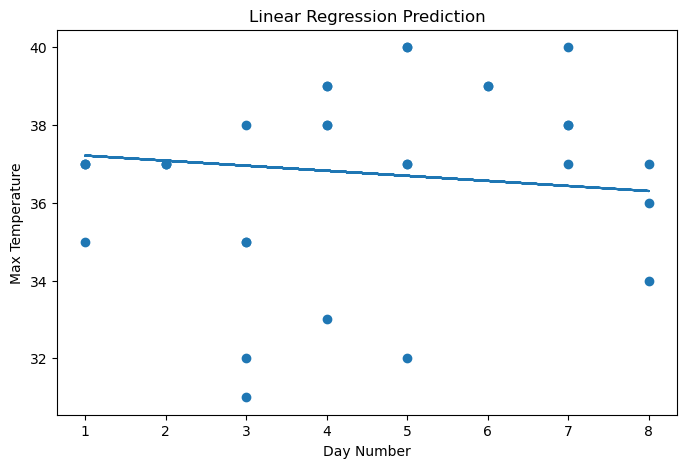

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)

plt.xlabel("Day Number")
plt.ylabel("Max Temperature")
plt.title("Linear Regression Prediction")

plt.show()